# Введение в нейронные сети. Домашняя работа

---

Скачиваем датасет, применяем трансформацию и выделяем валидационную выборку

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from IPython.display import clear_output
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.ToTensor()
mnist_train_full = datasets.MNIST(root='mnist', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='mnist', train=False, download=True, transform=transform)

train_size = int(0.8 * len(mnist_train_full))
val_size = len(mnist_train_full) - train_size
train_dataset, val_dataset = random_split(mnist_train_full, [train_size, val_size])

BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.79MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 157kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Напишем функции для отрисовки графиков, обучения и тестирования нашей нейросети

In [2]:
def show_learning_curves(train_losses, val_losses):
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.title('Loss History')
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Validation Loss', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('CrossEntropy Loss')
    plt.legend()
    plt.grid()
    plt.show()


def train_and_evaluate(model, epochs=10, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_function = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    min_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_function(pred, y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * X.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                loss = loss_function(pred, y)
                running_val_loss += loss.item() * X.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if epoch_val_loss < min_val_loss:
            min_val_loss = epoch_val_loss

        show_learning_curves(train_losses, val_losses)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    return min_val_loss


def evaluate_on_test(model):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.numpy())

    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, average='macro')
    rec = recall_score(all_targets, all_preds, average='macro')
    f1 = f1_score(all_targets, all_preds, average='macro')
    return acc, prec, rec, f1

Создадим несколько моделей для последующих подсчета числа параметров и оценки наших архитектуры и гиперпараметров

In [6]:
model_1 = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_2 = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.Linear(28 * 28, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)

model_3 = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.Linear(28 * 28, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)

model_4 = nn.Sequential(
    nn.Flatten(start_dim=1),
    nn.Linear(28 * 28, 256),
    nn.BatchNorm1d(256),
    nn.LeakyReLU(0.1),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.LeakyReLU(0.1),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)

experiments = {
    '1. Baseline': model_1,
    '2. Deep + Dropout': model_2,
    '3. Deep + BN + Dropout': model_3,
    '4. Deep + BN + Dropout + LeakyReLU': model_4
}

for name, model in experiments.items():
    params_count = sum(torch.numel(param) for param in model.parameters())
    print(f"Model: {name} | Total Parameters: {params_count}")

Model: 1. Baseline | Total Parameters: 101770
Model: 2. Deep + Dropout | Total Parameters: 235146
Model: 3. Deep + BN + Dropout | Total Parameters: 235914
Model: 4. Deep + BN + Dropout + LeakyReLU | Total Parameters: 235914


Оценим наши модели!

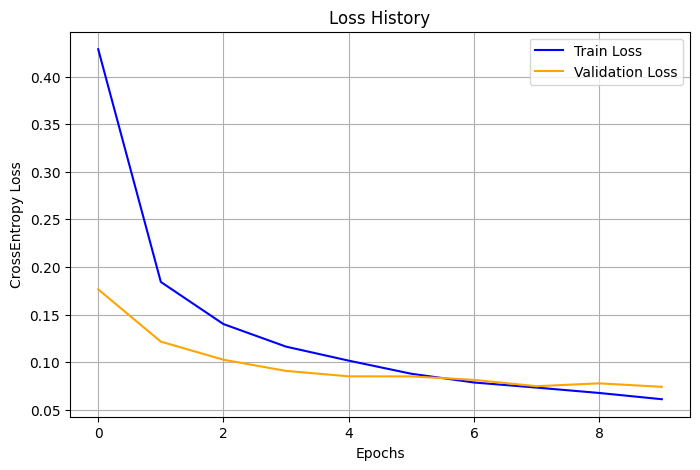

Epoch 10/10 | Train Loss: 0.0611 | Val Loss: 0.0741


,Номер эксперимента,Описание,Min Val Loss,Accuracy,Precision,Recall,F1-score
0,1,1. Baseline,0.1095,0.9701,0.9699,0.9699,0.9698
1,2,2. Deep + Dropout,0.0798,0.9786,0.9785,0.9785,0.9785
2,3,3. Deep + BN + Dropout,0.0683,0.9822,0.9821,0.9820,0.9820
3,4,4. Deep + BN + Dropout + LeakyReLU,0.0741,0.9780,0.9779,0.9778,0.9778


In [7]:
results = []

for exp_idx, (exp_name, model) in enumerate(experiments.items(), 1):
    print(f"\n--- Запуск эксперимента {exp_idx}: {exp_name} ---")

    min_val = train_and_evaluate(model, epochs=10, lr=1e-3)
    acc, prec, rec, f1 = evaluate_on_test(model)

    results.append({
        'Номер эксперимента': exp_idx,
        'Описание': exp_name,
        'Min Val Loss': round(min_val, 4),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4)
    })

df_report = pd.DataFrame(results)
df_report

Построенные графики обучения показывают, что все модели успешно сошлись (кривая обучающего лосса стабильно падает). У модели Baseline без регуляризации к концу эпох можно заметить довольно сильное расхождение кривых трейна и валидации, что свидетельствует о переобучении.

---
## Сравнение архитектур и выбор оптимальной:
Наилучший результат на тестовой выборке по метрике F1-score показала архитектура №3 (Deep + BatchNorm + Dropout).

### Почему именно эта архитектура?

1. Dropout: Добавление слоев Dropout снизило риск переобучения за счет случайного зануления весов, что заставило сеть выделять более независимые признаки.

2. BatchNorm: Использование BatchNorm1d значительно улучшило сходимость. Нормализация распределения входов на каждом скрытом слое позволила градиентам протекать более стабильно и предотвратила внутреннее *ковариатное смещение*.

При смене ReLU на ее Leaky-версию мы видим небольшое ухудшение наших метрик. Это может быть связано с простотой датасета: MNIST - датасет небольших черно-белых картинок, и слишком сложная нелинейность при классификации здешних изображений тут не нужна.